# Notebook - used for making some plots / testing

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from charpentier_sweep import CharpentierCWR
w, s, t = 10.0, 5.0, 0.1
geo = CharpentierCWR(w=w, s=s, t=t)
geo.build_geometry()
geo.generate_mesh(metal_mesh_size=0.005, bulk_mesh_size=2.0)

Info    : Meshing 1D...                                                                                     
Info    : [  0%] Meshing curve 17 (Line)
Info    : [ 10%] Meshing curve 18 (Line)
Info    : [ 20%] Meshing curve 19 (Line)
Info    : [ 20%] Meshing curve 20 (Line)
Info    : [ 30%] Meshing curve 21 (Line)
Info    : [ 30%] Meshing curve 22 (Line)
Info    : [ 40%] Meshing curve 23 (Line)
Info    : [ 40%] Meshing curve 24 (Line)
Info    : [ 50%] Meshing curve 25 (Line)
Info    : [ 50%] Meshing curve 26 (Line)
Info    : [ 60%] Meshing curve 27 (Line)
Info    : [ 60%] Meshing curve 28 (Line)
Info    : [ 70%] Meshing curve 29 (Line)
Info    : [ 70%] Meshing curve 30 (Line)
Info    : [ 80%] Meshing curve 31 (Line)
Info    : [ 80%] Meshing curve 32 (Line)
Info    : [ 90%] Meshing curve 33 (Line)
Info    : [ 90%] Meshing curve 34 (Line)
Info    : [100%] Meshing curve 35 (Line)
Info    : [100%] Meshing curve 36 (Line)
Info    : Done meshing 1D (Wall 2.09794s, CPU 3.14524s)
Info    : Meshi

(<Figure size 1500x900 with 1 Axes>,
 <Axes: title={'center': 'Finite Element Discretization'}, xlabel='x [μm]', ylabel='y [μm]'>)

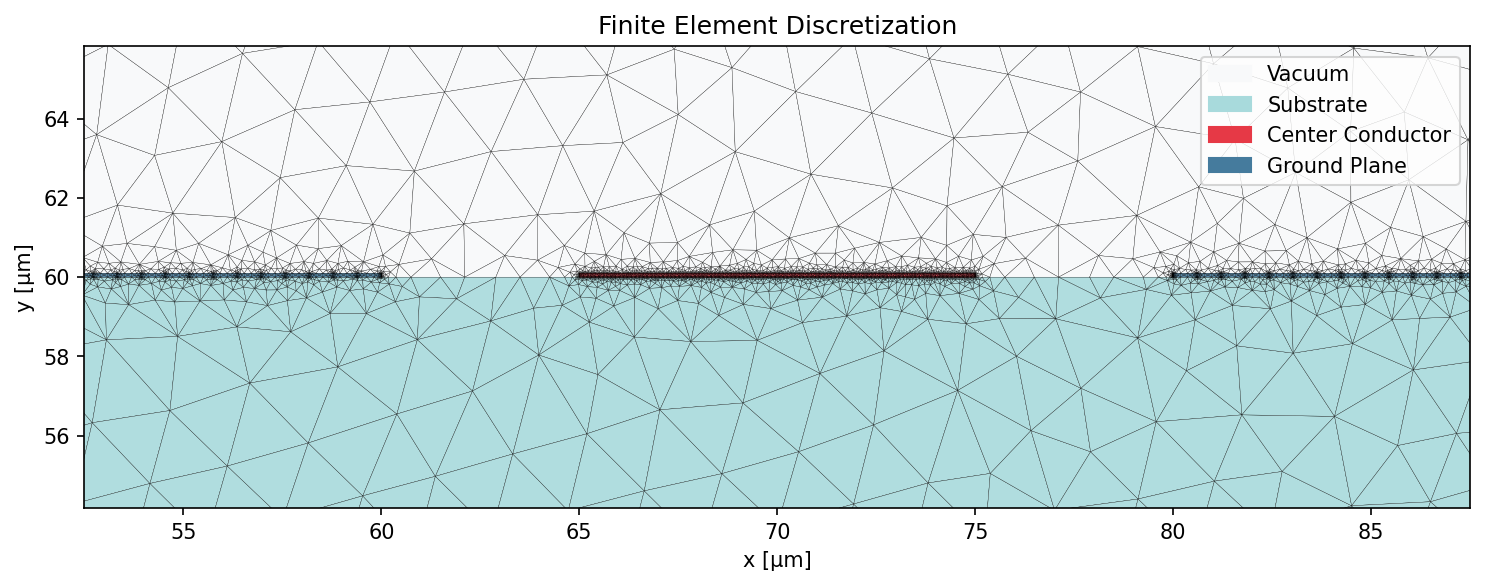

In [46]:
geo.plot_mesh(zoom_to_metal=True)

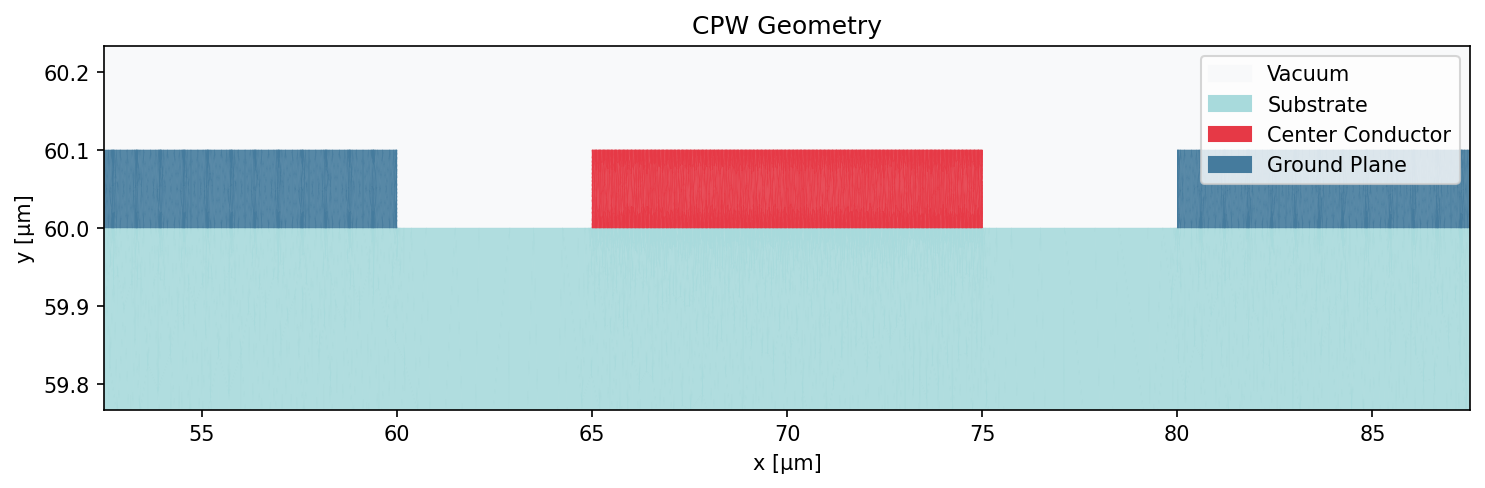

In [42]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Extract vertex coordinates and topological connectivity from FEniCSx
points = geo.domain.geometry.x[:, :2]
tdim = geo.domain.topology.dim
geo.domain.topology.create_connectivity(tdim, 0)
topology = geo.domain.topology.connectivity(tdim, 0).array.reshape((-1, 3))
ax = None
if ax is None:
    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
else:
    fig = ax.figure

# Define styles for specific regions
styles = {
    getattr(geo, 'TAG_DOMAIN', 1): ("#f8f9fa", "Vacuum"),
    getattr(geo, 'TAG_dielectric', 4): ("#a8dadc", "Substrate"),
    getattr(geo, 'TAG_METAL_CENTER', 31): ("#e63946", "Center Conductor"),
    getattr(geo, 'TAG_METAL_GND', 32): ("#457b9d", "Ground Plane"),
    getattr(geo, 'TAG_metal', 3): ("#1d3557", "Metal") # Fallback for normal CWR
}

legend_patches = [] # Store manual patches for the legend

# Iterate through physical groups and plot triangles
for tag, (color, label) in styles.items():
    mask = geo.cell_tags.values == tag
    if mask.sum() == 0:
        continue
    
    # edgecolors and linewidth explicitly render the mesh lattice
    # ax.tripcolor(
    #     points[:, 0], points[:, 1], topology[mask],
    #     facecolors=np.full(mask.sum(), 1.0),
    #     cmap=mpl.colors.ListedColormap([color]),
    #     edgecolors='black', lw=0.15, alpha=0.9
    # )
    

    ax.tripcolor(
                points[:, 0], points[:, 1], topology[mask],
                facecolors=np.full(mask.sum(), 1.0),
                cmap=mpl.colors.ListedColormap([color]),
                edgecolors='face', lw=0.2, alpha=0.9 
            )


    # Create a proxy artist for the legend
    legend_patches.append(mpatches.Patch(color=color, label=label))

ax.set_aspect('equal')
ax.set_xlabel('x [μm]')
ax.set_ylabel('y [μm]')
ax.set_title("CPW Geometry")

# Use the explicit proxy artists for the legend
ax.legend(handles=legend_patches, loc='upper right')

# Optional zooming to highlight the adaptive boundary layer

center_x = geo.Dx / 2

# Define how much of the horizontal layout to show 
x_span = 2 * (geo.w + geo.s * 1.5) 

# Force a pleasant aspect ratio for the bounding box (Width / Height)
aspect_ratio = 3.0 
y_span = x_span / 75

ax.set_xlim(center_x - x_span/2, center_x + x_span/2)
# Center the vertical view on the metal layer (y = geo.h)
ax.set_ylim(geo.h - y_span/2, geo.h + y_span/2)
ax.set_aspect(20)

plt.tight_layout()

In [44]:
geo.Dy

120.1

In [48]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.tri as mtri
from matplotlib.colors import LogNorm
from mpi4py import MPI
from dolfinx.io import gmsh as gmshio

# Import your classes
from CWR import CoplanarWaveguideResonator
from charpentier_sweep import CharpentierCWR
from quasi_tem_solver import QuasiTEMSolver

# 1. Geometry Setup (Using the cached adaptive mesh)
w, s, t = 10.0, 5.0, 0.1
geo = CharpentierCWR(w=w, s=s, t=t)
mesh_filename = "cached_cpw.msh"



print("Building mesh...")
geo.build_geometry()
geo.generate_mesh(metal_mesh_size=0.005, bulk_mesh_size=2.0, filename=mesh_filename)

# 2. Extract Topology for Matplotlib
points = geo.domain.geometry.x[:, :2]
tdim = geo.domain.topology.dim
geo.domain.topology.create_connectivity(tdim, 0)
topology = geo.domain.topology.connectivity(tdim, 0).array.reshape((-1, 3))
triang = mtri.Triangulation(points[:, 0], points[:, 1], topology)

# ==========================================
# 3. Solve Electrostatics (TLS Interface Focus)
# ==========================================
print("Solving Electrostatics...")
solver_elec = QuasiTEMSolver(geometry=geo, eps_substrate=11.7, degree=2)
solver_elec.solve_electrostatic(
    bc_high_tag=geo.TAG_BC_CENTER, 
    bc_low_tag=[geo.TAG_BC_GND, geo.TAG_BC_OUTER], 
    verbose=False
)
# Extract |E| on cells
E_mag = solver_elec._project_gradient_magnitude(solver_elec.phi)
# Mask out the metal domains (E = 0 inside PEC, log scale will crash)
metal_mask = (geo.cell_tags.values == geo.TAG_METAL_CENTER) | (geo.cell_tags.values == geo.TAG_METAL_GND)
E_mag[metal_mask] = 1e-15 

# ==========================================
# 4. Solve Magnetostatics (Charpentier Thin-Film Focus)
# ==========================================
print("Solving Magnetostatics (λ_L = 600 nm)...")
lam_um = 0.600 # 600 nm (Highly disordered thin-film regime)
transport_dict = {geo.TAG_METAL_CENTER: 1.0, geo.TAG_METAL_GND: 0.0}

solver_mag = QuasiTEMSolver(geometry=geo, eps_substrate=11.7, lambda_L=lam_um, degree=2)
solver_mag.solve_magnetostatic(
    bc_low_tag=geo.TAG_BC_OUTER, 
    sc_mode=True, 
    transport_cells=transport_dict, 
    verbose=False
)
# Extract J_z on cells
J_z = solver_mag.get_Jz_density(transport_dict)

# ==========================================
# 5. Figure Generation
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
center_x = geo.Dx / 2

# --- Panel 1: Electric Field Magnitude |E| ---
# LogNorm handles the massive dynamic range from the bulk to the edge singularities
tpc1 = ax1.tripcolor(
    triang, E_mag, 
    norm=LogNorm(vmin=1e-3, vmax=np.max(E_mag)), 
    cmap='magma', edgecolors='face', lw=0.1
)
ax1.set_aspect('equal')
ax1.set_xlim(center_x - w - s*1.5, center_x + w + s*1.5)
ax1.set_ylim(geo.h - t*5, geo.h + t*6)
ax1.set_title(r"Dielectric TLS Regime: Electric Field Magnitude $|\vec{E}|$")
ax1.set_xlabel('x [μm]')
ax1.set_ylabel('y [μm]')
fig.colorbar(tpc1, ax=ax1, fraction=0.046, pad=0.04, label=r"$|\vec{E}|$ (V/μm)")

# Add white outlines to define the metal traces against the dark background
for tag in [geo.TAG_METAL_CENTER, geo.TAG_METAL_GND]:
    mask = geo.cell_tags.values == tag
    ax1.tripcolor(triang.x, triang.y, triang.triangles[mask], facecolors=np.ones(mask.sum()), cmap='binary', alpha=0.1)

# --- Panel 2: Supercurrent Density J_z ---
# Mask J_z to only show values inside the metal (vacuum J_z = 0)
J_z_masked = np.copy(J_z)
J_z_masked[~metal_mask] = np.nan 

tpc2 = ax2.tripcolor(
    triang, J_z_masked, 
    cmap='viridis', edgecolors='face', lw=0.1
)
ax2.set_aspect('equal')
# Zoom extremely tight on the center conductor to show volumetric penetration
ax2.set_xlim(center_x - w/2 - 1.0, center_x + w/2 + 1.0)
ax2.set_ylim(geo.h - t*2, geo.h + t*3)
ax2.set_title(r"Charpentier Limit ($\lambda_L = 600$ nm): Supercurrent Density $J_z$")
ax2.set_xlabel('x [μm]')
fig.colorbar(tpc2, ax=ax2, fraction=0.046, pad=0.04, label=r"Scaled $J_z$")

# Shade the vacuum/substrate boundaries for context
vacuum_mask = geo.cell_tags.values == geo.TAG_DOMAIN
ax2.tripcolor(triang.x, triang.y, triang.triangles[vacuum_mask], facecolors=np.ones(vacuum_mask.sum()), cmap='gray', alpha=0.05)

plt.tight_layout()
plt.show()

Building mesh...
Info    : Meshing 1D...                                                                                     
Info    : [  0%] Meshing curve 17 (Line)
Info    : [ 10%] Meshing curve 18 (Line)
Info    : [ 20%] Meshing curve 19 (Line)
Info    : [ 20%] Meshing curve 20 (Line)
Info    : [ 30%] Meshing curve 21 (Line)
Info    : [ 30%] Meshing curve 22 (Line)
Info    : [ 40%] Meshing curve 23 (Line)
Info    : [ 40%] Meshing curve 24 (Line)
Info    : [ 50%] Meshing curve 25 (Line)
Info    : [ 50%] Meshing curve 26 (Line)
Info    : [ 60%] Meshing curve 27 (Line)
Info    : [ 60%] Meshing curve 28 (Line)
Info    : [ 70%] Meshing curve 29 (Line)
Info    : [ 70%] Meshing curve 30 (Line)
Info    : [ 80%] Meshing curve 31 (Line)
Info    : [ 80%] Meshing curve 32 (Line)
Info    : [ 90%] Meshing curve 33 (Line)
Info    : [ 90%] Meshing curve 34 (Line)
Info    : [100%] Meshing curve 35 (Line)
Info    : [100%] Meshing curve 36 (Line)
Info    : Done meshing 1D (Wall 2.07501s, CPU 3.09636s

AttributeError: 'QuasiTEMSolver' object has no attribute '_project_gradient_magnitude'